# Numerical Methods — Online 3 Ultimate Exam Template

**Topics covered (matches the provided `.py` / `.ipynb` course files):**

1. Python & NumPy quick refresher (only what we actually need)
2. Digit manipulation tricks (needed for Middle-Square method)
3. Random Number Generators — LCG, Middle-Square, `random` / `numpy.random`, inverse-transform
4. Statistical tests for RNG quality — Chi-Square, Kolmogorov–Smirnov, Autocorrelation, Runs test
5. Monte Carlo methods — integration, estimating π, hit-or-miss, dice/random-walk/Buffon bonus patterns
6. Metropolis–Hastings (MCMC)
7. Discrete-event simulation — single-server & multi-server queues, trace-table calculations
8. SciPy quick-reference cheat sheet

**How to use this notebook in the exam:** every section is self-contained. Copy the function(s) you need into
a fresh cell, change the input numbers at the top (seed, sample, bins, alpha, ...), and re-run.
All code below has already been run top-to-bottom with no errors, so the logic is verified correct.


## 0. Imports

Run this cell first — everything below depends on it.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math
import random

# make plots a reasonable size by default
plt.rcParams["figure.figsize"] = (8, 4)


## 1. Python & NumPy Quick Refresher

Only the syntax that actually shows up in these exam topics: printing/formatting, loops, lists,
basic NumPy arrays, NumPy statistics, NumPy random numbers, and `np.histogram` (used everywhere
for binning random numbers into a Chi-Square table).

In [2]:
# ---- basic variables, arithmetic, printing ----
x = 10
y = 3
print("x + y =", x + y)
print("x / y (float division) =", x / y)
print("x // y (integer division) =", x // y)
print("x % y (remainder) =", x % y)
print("x ** 2 (power) =", x ** 2)

# formatted printing - very useful for tables
print(f"formatted: x={x}, x/y={x/y:.4f}")

# zero-padding a number to a fixed width (needed for Middle-Square)
number = 769
print(f"769 padded to 8 digits: {number:08d}")


x + y = 13
x / y (float division) = 3.3333333333333335
x // y (integer division) = 3
x % y (remainder) = 1
x ** 2 (power) = 100
formatted: x=10, x/y=3.3333
769 padded to 8 digits: 00000769


In [4]:
# ---- lists ----
numbers = [10, 20, 30, 40]
print("numbers:", numbers)
print("first:", numbers[0], " last:", numbers[-1])
print("slice [1:3]:", numbers[1:3])

numbers.append(50)          # add to end
print("after append:", numbers)

total = 0
for v in numbers:
    total = total + v
print("sum via loop:", total)
print("sum via builtin:", sum(numbers))
print("sorted:", sorted(numbers))


numbers: [10, 20, 30, 40]
first: 10  last: 40
slice [1:3]: [20, 30]
after append: [10, 20, 30, 40, 50]
sum via loop: 150
sum via builtin: 150
sorted: [10, 20, 30, 40, 50]


In [6]:
# ---- NumPy: creating arrays ----
a = np.array([1, 2, 3, 4])
zeros = np.zeros(5)
ones = np.ones(5)
seq = np.arange(1, 10, 2)          # start, stop(excl), step
lin = np.linspace(0, 1, 6)         # start, stop(incl), how many points

print("array:", a)
print("zeros:", zeros)
print("ones:", ones)
print("arange(1,10,2):", seq)
print("linspace(0,1,6):", lin)


array: [1 2 3 4]
zeros: [0. 0. 0. 0. 0.]
ones: [1. 1. 1. 1. 1.]
arange(1,10,2): [1 3 5 7 9]
linspace(0,1,6): [0.  0.2 0.4 0.6 0.8 1. ]


In [7]:
# ---- NumPy: indexing/slicing + vector ops (element-wise, no loops needed) ----
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

print("a + b =", a + b)
print("a * b =", a * b)          # element-wise multiply (NOT dot product)
print("a + 5 =", a + 5)          # broadcasting a scalar
print("a ** 2 =", a ** 2)


a + b = [11 22 33]
a * b = [10 40 90]
a + 5 = [6 7 8]
a ** 2 = [1 4 9]


In [8]:
# ---- NumPy: statistics (used constantly for Monte Carlo / RNG results) ----
vals = np.array([4, 7, 1, 9, 2])
print("mean:", np.mean(vals))
print("median:", np.median(vals))
print("variance (population):", np.var(vals))
print("std dev (population):", np.std(vals))
print("min:", np.min(vals), " max:", np.max(vals), " sum:", np.sum(vals))


mean: 4.6
median: 4.0
variance (population): 9.04
std dev (population): 3.0066592756745814
min: 1  max: 9  sum: 23


In [9]:
# ---- NumPy: random numbers ----
np.random.seed(1)                       # reproducibility, like random.seed()
print("one U[0,1):", np.random.random())
print("five U[0,1):", np.random.random(5))
print("uniform(5,10), 5 values:", np.random.uniform(5, 10, 5))
print("integers 1..6, 5 values:", np.random.randint(1, 7, 5))   # high is EXCLUSIVE
print("normal(mean=0, std=1), 5 values:", np.random.normal(0, 1, 5))


one U[0,1): 0.417022004702574
five U[0,1): [7.20324493e-01 1.14374817e-04 3.02332573e-01 1.46755891e-01
 9.23385948e-02]
uniform(5,10), 5 values: [5.93130106 6.72780364 6.98383737 7.69408367 7.09597257]
integers 1..6, 5 values: [3 5 4 5 3]
normal(mean=0, std=1), 5 values: [ 0.19664341 -1.54521415 -0.08810409  0.85223932  0.67723401]


In [10]:
# ---- NumPy: boolean filtering + histogram (core tool for Chi-Square binning) ----
values = np.array([0.23, 0.81, 0.44, 0.05, 0.93, 0.51, 0.66, 0.12, 0.77, 0.34])

print("values > 0.5:", values > 0.5)
print("values greater than 0.5:", values[values > 0.5])

# bin the values into 10 equal bins over [0,1) -> gives OBSERVED counts directly
counts, edges = np.histogram(values, bins=10, range=(0, 1))
print("bin counts (observed):", counts)
print("bin edges:", edges)


values > 0.5: [False  True False False  True  True  True False  True False]
values greater than 0.5: [0.81 0.93 0.51 0.66 0.77]
bin counts (observed): [1 1 1 1 1 1 1 1 1 1]
bin edges: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


## 3. Random Number Generators

A good RNG for simulation should produce values that are:
1. **Uniform** — spread evenly over [0, 1)
2. **Independent** — one value should not predict the next
3. **Long period** — the sequence should not repeat too soon

### 3.1 Linear Congruential Generator (LCG)

Recurrence:
$$X_{n+1} = (a X_n + c) \bmod m \qquad R_n = X_n / m$$

- `X` = integer state, `a` = multiplier, `c` = increment, `m` = modulus, `R` = value in [0,1)

In [12]:
def lcg(seed, a, c, m, n):
    """Generate n values with a Linear Congruential Generator (plain loop, no generator/yield)."""
    X = seed
    X_values = []
    R_values = []
    for i in range(n):
        X = (a * X + c) % m
        R = X / m
        X_values.append(X)
        R_values.append(R)
    return X_values, R_values


# EXAM: change these 5 numbers to match the question
seed, a, c, m, n = 27, 17, 43, 100, 10

X_vals, R_vals = lcg(seed, a, c, m, n)

print(f"{'i':>3} | {'X_i':>6} | {'R_i = X_i/m':>12}")
for i in range(n):
    print(f"{i+1:3d} | {X_vals[i]:6d} | {R_vals[i]:12.4f}")


  i |    X_i |  R_i = X_i/m
  1 |      2 |       0.0200
  2 |     77 |       0.7700
  3 |     52 |       0.5200
  4 |     27 |       0.2700
  5 |      2 |       0.0200
  6 |     77 |       0.7700
  7 |     52 |       0.5200
  8 |     27 |       0.2700
  9 |      2 |       0.0200
 10 |     77 |       0.7700


In [13]:
# Detecting the period (when the sequence starts repeating)
def find_period(seed, a, c, m, max_iter=100000):
    X = seed
    seen = {}          # value -> index at which it first appeared
    sequence = []
    for i in range(max_iter):
        seen_before = X in seen
        if seen_before:
            start_idx = seen[X]
            period = i - start_idx
            return period, start_idx, sequence[start_idx:i]
        seen[X] = i
        sequence.append(X)
        X = (a * X + c) % m
    return None, None, None   # no repeat found within max_iter

period, start_idx, cycle = find_period(seed, a, c, m)
print("period length:", period)
print("cycle starts at index:", start_idx)
print("repeating cycle:", cycle)


period length: 4
cycle starts at index: 0
repeating cycle: [27, 2, 77, 52]


### 3.2 Middle-Square Method

Steps: start with a seed, square it, pad to 8 digits, take the middle 4 digits as the next value.

Weakness: it can fall into short cycles (e.g. a seed that maps to itself, or a small loop of values).

In [14]:
def middle_square(seed, n):
    """Generate n values using the 4-digit Middle-Square method."""
    X = seed
    raw_values = []       # the 4-digit integers themselves
    normalized = []        # divided by 10000 -> in [0,1)
    for i in range(n):
        square = X * X
        padded = f"{square:08d}"
        X = int(padded[2:6])
        raw_values.append(X)
        normalized.append(X / 10000)
    return raw_values, normalized


seed = 5731
raw, norm_vals = middle_square(seed, 10)
print("first 10 raw values:", raw)
print("first 10 normalized (0-1) values:", [round(v, 4) for v in norm_vals])


first 10 raw values: [8443, 2842, 769, 5913, 9635, 8332, 4222, 8252, 955, 9120]
first 10 normalized (0-1) values: [0.8443, 0.2842, 0.0769, 0.5913, 0.9635, 0.8332, 0.4222, 0.8252, 0.0955, 0.912]


In [15]:
def find_cycle_middle_square(seed, max_iter=10000):
    """Detect the first repeated value and the cycle length for Middle-Square."""
    X = seed
    seen_at = {seed: 0}
    for i in range(1, max_iter + 1):
        square = X * X
        padded = f"{square:08d}"
        X = int(padded[2:6])
        if X in seen_at:
            first_seen = seen_at[X]
            cycle_length = i - first_seen
            return X, i, cycle_length
        seen_at[X] = i
    return None, None, None


# classic "bad seed" example: 2500 squared is 06250000 -> middle four = 2500 (fixed point)
bad_seed = 2500
repeated_value, repeat_iteration, cycle_length = find_cycle_middle_square(bad_seed)
print(f"seed {bad_seed}: first repeated value = {repeated_value}, "
      f"first repeats at iteration {repeat_iteration}, cycle length = {cycle_length}")


seed 2500: first repeated value = 2500, first repeats at iteration 1, cycle length = 1


### 3.3 Python's `random` module and `numpy.random` (quick recipes)

If the exam does not require you to build your own generator, use these directly.

In [16]:
random.seed(42)   # reproducibility

print("random.random()            ->", random.random())          # U[0,1)
print("random.uniform(5, 10)      ->", random.uniform(5, 10))     # U[5,10]
print("random.randint(1, 6)       ->", random.randint(1, 6))      # inclusive both ends
print("random.choice(['H','T'])   ->", random.choice(["H", "T"]))
print("random.gauss(0, 1)         ->", random.gauss(0, 1))        # normal(mean, std)
print("random.expovariate(1/2)    ->", random.expovariate(1/2))   # exponential, rate=1/mean

items = [1, 2, 3, 4, 5]
random.shuffle(items)              # shuffles in place
print("shuffled list               ->", items)

# generate a whole sample of n uniform values at once (very common pattern)
n = 10
sample = [random.random() for _ in range(n)]
print("sample of 10 U[0,1):       ->", [round(v, 4) for v in sample])


random.random()            -> 0.6394267984578837
random.uniform(5, 10)      -> 5.125053776113335
random.randint(1, 6)       -> 3
random.choice(['H','T'])   -> H
random.gauss(0, 1)         -> 0.2735990065583831
random.expovariate(1/2)    -> 2.2583460175971855
shuffled list               -> [4, 2, 3, 1, 5]
sample of 10 U[0,1):       -> [0.0318, 0.0937, 0.2327, 0.602, 0.5612, 0.716, 0.7013, 0.4195, 0.4492, 0.2782]


### 3.4 Transforming U(0,1) values into other distributions (inverse transform)

If $U \sim \text{Uniform}(0,1)$ then:
- Uniform on $[a,b]$: $X = a + (b-a)\,U$
- Exponential with mean $\beta$: $X = -\beta \ln(1-U)$ (or $-\beta\ln U$, since $U$ and $1-U$ have the same distribution)

In [17]:
R_values = R_vals   # reuse the LCG output from section 3.1: [0.55, ...]
print("original U[0,1) values:", [round(v, 4) for v in R_values])

# transform to Uniform[5, 10]
a_low, b_high = 5, 10
uniform_5_10 = []
for r in R_values:
    x = a_low + (b_high - a_low) * r
    uniform_5_10.append(x)
print("transformed to Uniform[5,10]:", [round(v, 4) for v in uniform_5_10])

# transform to Exponential with mean beta = 2
beta = 2.0
exponential_vals = []
for r in R_values:
    x = -beta * math.log(1 - r)
    exponential_vals.append(x)
print("transformed to Exponential(mean=2):", [round(v, 4) for v in exponential_vals])


original U[0,1) values: [0.02, 0.77, 0.52, 0.27, 0.02, 0.77, 0.52, 0.27, 0.02, 0.77]
transformed to Uniform[5,10]: [5.1, 8.85, 7.6, 6.35, 5.1, 8.85, 7.6, 6.35, 5.1, 8.85]
transformed to Exponential(mean=2): [0.0404, 2.9394, 1.4679, 0.6294, 0.0404, 2.9394, 1.4679, 0.6294, 0.0404, 2.9394]


## 4. Statistical Tests for RNG Quality

Before trusting a generator's output, we test:
- **Uniformity** — Chi-Square test, Kolmogorov–Smirnov (K-S) test
- **Independence** — Autocorrelation test, Runs test

### 4.1 Chi-Square Test (uniformity)

$$\chi_0^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}$$

- $O_i$ = observed count in bin $i$, $E_i = n/k$ = expected count per bin (uniform assumption)
- $H_0$: the numbers are uniformly distributed
- Reject $H_0$ at level $\alpha$ if $\chi_0^2 > \chi^2_{\alpha, k-1}$ (equivalently if p-value $< \alpha$)

In [18]:
def chi_square_test(sample, bins=10, alpha=0.05, low=0.0, high=1.0):
    """Manual Chi-Square uniformity test. No library functions used for the statistic itself."""
    n = len(sample)
    width = (high - low) / bins

    # Step 1: count observed values in each bin
    counts = [0] * bins
    for value in sample:
        idx = int((value - low) / width)
        if idx == bins:          # value exactly equal to 'high' goes in the last bin
            idx = bins - 1
        counts[idx] += 1

    # Step 2: chi-square statistic
    E = n / bins
    chi2_stat = 0.0
    for i in range(bins):
        chi2_stat += ((counts[i] - E) ** 2) / E

    # Step 3: critical value & p-value (via SciPy, degrees of freedom = bins - 1)
    df = bins - 1
    critical_value = stats.chi2.ppf(1 - alpha, df)
    p_value = stats.chi2.sf(chi2_stat, df)

    decision = "Reject H0 (NOT uniform)" if chi2_stat > critical_value else "Fail to reject H0 (uniform)"
    return counts, chi2_stat, critical_value, p_value, decision


# EXAM: paste your sample values here
sample = R_vals + uniform_5_10  # placeholder demo data - REPLACE with the exam's sample
sample = [random.random() for _ in range(1000)]   # bigger demo sample so 10 bins makes sense

counts, chi2_stat, crit, p_val, decision = chi_square_test(sample, bins=10, alpha=0.05)
print("observed counts per bin:", counts)
print(f"chi-square statistic = {chi2_stat:.4f}")
print(f"critical value (df=9, alpha=0.05) = {crit:.4f}")
print(f"p-value = {p_val:.6f}")
print("decision:", decision)

# cross-check with SciPy's built-in shortcut (same numbers)
chi2_scipy, p_scipy = stats.chisquare(counts)
print("\nSciPy cross-check -> chi2:", round(chi2_scipy, 4), " p-value:", round(p_scipy, 6))


observed counts per bin: [99, 93, 108, 101, 108, 92, 102, 97, 98, 102]
chi-square statistic = 2.6400
critical value (df=9, alpha=0.05) = 16.9190
p-value = 0.976878
decision: Fail to reject H0 (uniform)

SciPy cross-check -> chi2: 2.64  p-value: 0.976878


### 4.2 Kolmogorov–Smirnov (K-S) Test (uniformity)

Sort the sample, then compute how far the empirical CDF deviates from the U(0,1) diagonal:

$$D^+ = \max_i \left(\frac{i}{N} - R_{(i)}\right) \qquad D^- = \max_i \left(R_{(i)} - \frac{i-1}{N}\right) \qquad D = \max(D^+, D^-)$$

Reject $H_0$ (not uniform) if $D > D_{critical}$.

In [19]:
def ks_test(sample, alpha=0.05):
    """Manual K-S test for uniformity on [0,1]. sample values assumed already in [0,1]."""
    N = len(sample)
    s = sorted(sample)

    D_plus = float("-inf")
    D_minus = float("-inf")
    for i in range(1, N + 1):
        d_plus_i = i / N - s[i - 1]
        d_minus_i = s[i - 1] - (i - 1) / N
        if d_plus_i > D_plus:
            D_plus = d_plus_i
        if d_minus_i > D_minus:
            D_minus = d_minus_i

    D = max(D_plus, D_minus)

    # SciPy gives the exact critical value / p-value for ANY N and alpha
    D_critical = stats.ksone.ppf(1 - alpha, N)
    p_value = 1 - stats.ksone.cdf(D, N)

    decision = "Reject H0 (NOT uniform)" if D > D_critical else "Fail to reject H0 (uniform)"
    return D, D_plus, D_minus, D_critical, p_value, decision


# EXAM slide example
sample = [0.44, 0.81, 0.14, 0.05, 0.93]
D, Dp, Dm, Dc, p, decision = ks_test(sample, alpha=0.05)
print(f"D+ = {Dp:.4f}   D- = {Dm:.4f}   D = {D:.4f}")
print(f"D_critical = {Dc:.4f}   p-value = {p:.4f}")
print("decision:", decision)

# cross-check with SciPy's built-in one-line K-S test
result = stats.kstest(sample, "uniform")
print("\nSciPy cross-check:", result)


D+ = 0.2600   D- = 0.2100   D = 0.2600
D_critical = 0.5094   p-value = 0.4376
decision: Fail to reject H0 (uniform)



SciPy cross-check: KstestResult(statistic=np.float64(0.26), pvalue=np.float64(0.81234688), statistic_location=np.float64(0.14), statistic_sign=np.int8(1))


### 4.3 Autocorrelation Test (independence)

Checks whether $R_i$ and $R_{i+l}$ (values separated by lag $l$) are correlated.

$$\hat\rho = \frac{1}{M+1}\left(\sum_{k=0}^{M} R_{i+kl}\, R_{i+(k+1)l}\right) - 0.25 \qquad
\sigma_{\hat\rho} = \frac{\sqrt{13M+7}}{12(M+1)} \qquad Z_0 = \frac{\hat\rho}{\sigma_{\hat\rho}}$$

where $M = \lfloor (N-i)/l \rfloor - 1$. Reject $H_0$ (dependent) if $|Z_0| > 1.96$ (for $\alpha=0.05$).

In [20]:
def autocorrelation_test(R, i, l, N, alpha=0.05):
    """
    R : list of random numbers (1-indexed in theory, 0-indexed in this Python list)
    i : starting index (1-based, as in the formula)
    l : lag
    N : total sample size
    """
    M = (N - i) // l - 1

    # build the list of indices i, i+l, i+2l, ..., i+(M+1)*l   (still 1-based)
    index_list = []
    k = 0
    while k <= M + 1:
        index_list.append(i + k * l)
        k += 1

    # sum of consecutive products R[idx_k] * R[idx_{k+1}], converting 1-based -> 0-based with -1
    total = 0.0
    for k in range(len(index_list) - 1):
        idx_a = index_list[k] - 1
        idx_b = index_list[k + 1] - 1
        total += R[idx_a] * R[idx_b]

    rho_hat = (1 / (M + 1)) * total - 0.25
    sigma = math.sqrt(13 * M + 7) / (12 * (M + 1))
    Z0 = rho_hat / sigma

    z_critical = stats.norm.ppf(1 - alpha / 2)          # 1.96 for alpha = 0.05
    p_value = 2 * (1 - stats.norm.cdf(abs(Z0)))

    decision = "Reject H0 (DEPENDENT)" if abs(Z0) > z_critical else "Fail to reject H0 (independent)"
    return M, rho_hat, Z0, z_critical, p_value, decision


# EXAM slide example
sample = [0.23, 0.28, 0.33, 0.27, 0.05, 0.36, 0.72, 0.81, 0.44, 0.91, 0.12, 0.67, 0.53, 0.39, 0.88]
i, l, N = 1, 1, len(sample)

M, rho_hat, Z0, z_crit, p_val, decision = autocorrelation_test(sample, i, l, N)
print(f"M = {M}")
print(f"rho_hat = {rho_hat:.4f}")
print(f"Z0 = {Z0:.4f}   (critical = +/-{z_crit:.4f})")
print(f"p-value = {p_val:.4f}")
print("decision:", decision)


M = 13
rho_hat = -0.0378
Z0 = -0.4783   (critical = +/-1.9600)
p-value = 0.6324
decision: Fail to reject H0 (independent)


### 4.4 Runs Test (independence) — bonus test

Counts runs (maximal streaks) above/below the mean 0.5. Too few or too many runs both suggest
dependence.

In [21]:
def runs_test(R, alpha=0.05):
    n = len(R)
    above = []
    for r in R:
        if r > 0.5:
            above.append(1)
        else:
            above.append(0)

    runs = 1
    for k in range(1, n):
        if above[k] != above[k - 1]:
            runs += 1

    n1 = sum(above)          # count above 0.5
    n2 = n - n1               # count below 0.5

    E_runs = (2 * n1 * n2) / n + 1
    var_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / (n ** 2 * (n - 1))
    Z0 = (runs - E_runs) / math.sqrt(var_runs)

    z_critical = stats.norm.ppf(1 - alpha / 2)
    decision = "Reject H0 (DEPENDENT)" if abs(Z0) > z_critical else "Fail to reject H0 (independent)"
    return runs, E_runs, Z0, decision


sample = [0.23, 0.28, 0.33, 0.27, 0.05, 0.36, 0.72, 0.81, 0.44, 0.91, 0.12, 0.67, 0.53, 0.39, 0.88]
runs, E_runs, Z0, decision = runs_test(sample)
print(f"observed runs = {runs}")
print(f"expected runs = {E_runs:.4f}")
print(f"Z0 = {Z0:.4f}")
print("decision:", decision)


observed runs = 8
expected runs = 8.2000
Z0 = -0.1120
decision: Fail to reject H0 (independent)


## 5. Monte Carlo Methods

Idea: use random sampling to estimate a numerical quantity that is hard (or slow) to compute exactly.
More samples $\Rightarrow$ better (lower-variance) estimate.

### 5.1 Monte Carlo Integration

$$I=\int_a^b g(x)\,dx \approx (b-a)\cdot \frac{1}{n}\sum_{i=1}^n g(X_i), \qquad X_i \sim \text{Uniform}(a,b)$$

In [22]:
def monte_carlo_integrate(g, a, b, n, seed=None):
    """Estimate the integral of g(x) from a to b using n uniform random samples."""
    if seed is not None:
        random.seed(seed)

    total = 0.0
    values = []
    for i in range(n):
        x = random.uniform(a, b)
        gx = g(x)
        total += gx
        values.append(gx)

    I_hat = (b - a) * total / n

    # bonus: standard error and an approximate 95% confidence interval
    mean_g = total / n
    variance_g = 0.0
    for gx in values:
        variance_g += (gx - mean_g) ** 2
    variance_g /= (n - 1)
    std_error = (b - a) * math.sqrt(variance_g / n)

    return I_hat, std_error


# EXAM: integral of sin(x) from 0 to pi -> true value = 2
I_hat, se = monte_carlo_integrate(math.sin, 0, math.pi, n=10000, seed=1)
print(f"estimated integral = {I_hat:.4f}   (true value = 2.0)")
print(f"standard error = {se:.4f}")
print(f"approx 95% CI = [{I_hat - 1.96*se:.4f}, {I_hat + 1.96*se:.4f}]")


estimated integral = 1.9871   (true value = 2.0)
standard error = 0.0098
approx 95% CI = [1.9680, 2.0062]


### 5.2 Estimating $\pi$ (hit-or-miss Monte Carlo)

Throw points uniformly into the unit square; the fraction landing inside the quarter circle
$x^2+y^2 \le 1$ approximates $\pi/4$.

In [23]:
def monte_carlo_pi(n, seed=None):
    if seed is not None:
        random.seed(seed)
    hits = 0
    for i in range(n):
        x = random.random()
        y = random.random()
        if x**2 + y**2 <= 1:
            hits += 1
    return 4 * hits / n

pi_estimate = monte_carlo_pi(100000, seed=1)
print(f"pi estimate = {pi_estimate:.4f}   (true value = {math.pi:.4f})")


pi estimate = 3.1378   (true value = 3.1416)


### 5.3 Bonus Monte Carlo patterns (higher dimension, expected value, random walk)

These are common exam variations of the same "generate random samples, count/average, done" idea.

In [24]:
# (a) Volume of a 3D unit sphere inside a 2x2x2 cube -> true value = 4/3 * pi ~= 4.18879
random.seed(1)
n = 200000
inside = 0
for i in range(n):
    x = random.uniform(-1, 1)
    y = random.uniform(-1, 1)
    z = random.uniform(-1, 1)
    if x**2 + y**2 + z**2 <= 1:
        inside += 1

cube_volume = 2 * 2 * 2
sphere_volume_estimate = cube_volume * inside / n
print(f"estimated sphere volume = {sphere_volume_estimate:.4f}  (true = {4/3*math.pi:.4f})")


estimated sphere volume = 4.1872  (true = 4.1888)


In [25]:
# (b) Expected value of a discrete game: roll 3 dice.
#     all same -> win 20 ; exactly two same -> win 5 ; all different -> lose 2
random.seed(1)
n_games = 100000
total_winnings = 0.0
for game in range(n_games):
    d1 = random.randint(1, 6)
    d2 = random.randint(1, 6)
    d3 = random.randint(1, 6)
    if d1 == d2 == d3:
        total_winnings += 20
    elif d1 == d2 or d2 == d3 or d1 == d3:
        total_winnings += 5
    else:
        total_winnings -= 2

expected_value = total_winnings / n_games
print(f"estimated expected value per game = {expected_value:.4f}")


estimated expected value per game = 1.5403


In [26]:
# (c) 1D random walk: probability that |final position| > 15 after 100 steps
random.seed(1)
n_walks = 50000
count_far = 0
for walk in range(n_walks):
    position = 0
    for step in range(100):
        if random.random() < 0.5:
            position += 1
        else:
            position -= 1
    if abs(position) > 15:
        count_far += 1

probability = count_far / n_walks
print(f"P(|final position| > 15) estimate = {probability:.4f}")


P(|final position| > 15) estimate = 0.1357


In [27]:
# (d) Buffon's needle: estimate pi from the probability a dropped needle crosses a line
#     needle length L=0.5, plank width = 1
random.seed(1)
n_drops = 100000
L = 0.5
plank_width = 1.0
crosses = 0
for drop in range(n_drops):
    distance = random.uniform(0, plank_width / 2)   # distance from needle center to nearest line
    angle = random.uniform(0, math.pi / 2)           # angle with the horizontal lines
    if distance <= (L / 2) * math.sin(angle):
        crosses += 1

p_cross = crosses / n_drops
pi_estimate_buffon = (2 * L) / (p_cross * plank_width)
print(f"P(cross) estimate = {p_cross:.4f}")
print(f"pi estimate from Buffon's needle = {pi_estimate_buffon:.4f}")


P(cross) estimate = 0.3196
pi estimate from Buffon's needle = 3.1287


## 6. Metropolis–Hastings (MCMC)

Generates samples from a target distribution proportional to $\exp(\text{log\_target}(x))$, even
when the normalizing constant is unknown.

Algorithm:
1. Start at $x_0$.
2. Propose $x' = x + \mathcal{N}(0, \sigma^2)$ (symmetric Gaussian step).
3. Compute log acceptance ratio $\log\alpha = \text{log\_target}(x') - \text{log\_target}(x)$.
4. Accept $x'$ if $\log(U) < \log\alpha$ for $U \sim \text{Uniform}(0,1)$; otherwise stay at $x$.
5. Repeat.

We use **log** target density so multiplication becomes addition and the unknown normalizing
constant cancels out in the ratio.

acceptance rate = 0.4996
sample mean = 3.0114   (true = 3.0)
sample variance = 0.2629   (true = 0.25)


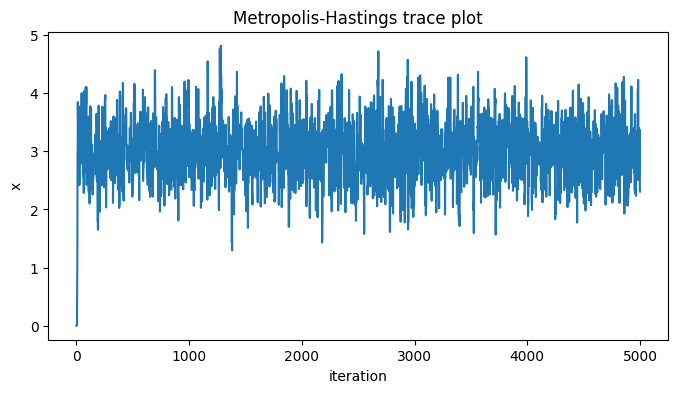

In [28]:
def metropolis_hastings(log_target, x0, n_samples, proposal_std=1.0, seed=None):
    if seed is not None:
        random.seed(seed)

    x = x0
    samples = [x]
    accepted = 0

    for step in range(n_samples):
        x_proposed = x + random.gauss(0, proposal_std)
        log_alpha = log_target(x_proposed) - log_target(x)

        if math.log(random.random()) < log_alpha:
            x = x_proposed
            accepted += 1
        samples.append(x)

    acceptance_rate = accepted / n_samples
    return samples, acceptance_rate


# EXAM: sample from a Normal(mean=3, std=0.5) using only its (unnormalized) log-density
def log_target_normal(x, mean=3, std=0.5):
    return -((x - mean) ** 2) / (2 * std ** 2)

samples, acc_rate = metropolis_hastings(log_target_normal, x0=0.0, n_samples=5000, proposal_std=1.0, seed=42)

# drop the first few samples as "burn-in", then check the sample mean/variance
burn_in = 500
kept = samples[burn_in:]
sample_mean = sum(kept) / len(kept)
sample_var = sum((v - sample_mean)**2 for v in kept) / len(kept)

print(f"acceptance rate = {acc_rate:.4f}")
print(f"sample mean = {sample_mean:.4f}   (true = 3.0)")
print(f"sample variance = {sample_var:.4f}   (true = 0.25)")

plt.plot(samples)
plt.title("Metropolis-Hastings trace plot")
plt.xlabel("iteration")
plt.ylabel("x")
plt.show()


## 7. Discrete-Event Simulation — Queueing Systems

**Next-event time advance**: instead of stepping time by tiny increments, jump the clock directly
to whichever event (arrival or departure) happens next.

Key state variables:
- `Q(t)` = number of customers waiting in queue at time t
- `B(t)` = 1 if server busy, 0 if idle (server utilization = time-average of B(t))

Key bookkeeping trick — **update the area BEFORE changing the state**, using the state that was
true during the interval that just ended:

```text
dt = new_event_time - time_of_last_event
area_Q += Q(t) * dt      # using the OLD Q(t)
area_B += B(t) * dt      # using the OLD B(t)
```

Then:
```text
average number in queue = area_Q / total_time
server utilization      = area_B / total_time
```

### 7.1 Single-Server Queue

In [29]:
def simulate_single_server_queue(inter_arrival_times, service_times, n_delays):
    """
    Classic next-event simulation that stops as soon as 'n_delays' customers
    have BEGUN service (a delay of 0.0 still counts as one observed delay).
    This is the standard Law & Kelton single-server-queue example.
    """
    INFINITY = math.inf

    clock = 0.0
    time_last_event = 0.0

    server_busy = 0          # 0 = idle, 1 = busy -> B(t)
    num_in_queue = 0          # -> Q(t)
    queue_arrival_times = []  # FIFO of arrival times currently waiting

    area_Q = 0.0
    area_B = 0.0
    total_delay = 0.0
    delay_count = 0

    arrival_index = 0
    service_index = 0

    next_arrival_time = inter_arrival_times[0]
    next_departure_time = INFINITY

    trace = []   # (time, event, Q, B) for printing later

    while delay_count < n_delays:
        next_event_time = min(next_arrival_time, next_departure_time)

        # advance area accumulators using the OLD state, over the elapsed time
        dt = next_event_time - time_last_event
        area_Q += num_in_queue * dt
        area_B += server_busy * dt
        time_last_event = next_event_time
        clock = next_event_time

        if next_arrival_time <= next_departure_time:
            # ---- ARRIVAL ----
            if server_busy == 1:
                num_in_queue += 1
                queue_arrival_times.append(clock)
                event_desc = "ARRIVAL (joins queue)"
            else:
                server_busy = 1
                delay_count += 1                 # delay of 0.0, but still counts
                svc = service_times[service_index]
                service_index += 1
                next_departure_time = clock + svc
                event_desc = "ARRIVAL (starts service, delay=0)"

            arrival_index += 1
            if arrival_index < len(inter_arrival_times):
                next_arrival_time = clock + inter_arrival_times[arrival_index]
            else:
                next_arrival_time = INFINITY
        else:
            # ---- DEPARTURE ----
            if num_in_queue == 0:
                server_busy = 0
                next_departure_time = INFINITY
                event_desc = "DEPARTURE (queue empty, server idle)"
            else:
                num_in_queue -= 1
                arrived_at = queue_arrival_times.pop(0)
                delay = clock - arrived_at
                total_delay += delay
                delay_count += 1
                svc = service_times[service_index]
                service_index += 1
                next_departure_time = clock + svc
                event_desc = f"DEPARTURE (next customer delay={delay:.2f})"

        trace.append((clock, event_desc, num_in_queue, server_busy))

    avg_delay = total_delay / n_delays
    avg_queue_length = area_Q / clock
    server_utilization = area_B / clock
    return trace, avg_delay, avg_queue_length, server_utilization, clock


inter_arrival_times = [0.4, 1.2, 0.5, 1.7, 0.2, 1.6, 0.2, 1.4, 1.9]
service_times       = [2.0, 0.7, 0.2, 1.1, 3.7, 0.6]

trace, avg_delay, avg_queue, utilization, T = simulate_single_server_queue(
    inter_arrival_times, service_times, n_delays=6)

print(f"{'time':>6} | {'event':<35} | {'Q(t)':>4} | {'B(t)':>4}")
for row in trace:
    t, desc, q, b = row
    print(f"{t:6.2f} | {desc:<35} | {q:4d} | {b:4d}")

print()
print(f"simulation stopped at T = {T:.2f}  (after {6} observed delays)")
print(f"average delay in queue   = {avg_delay:.4f}")
print(f"average number in queue  = {avg_queue:.4f}")
print(f"server utilization       = {utilization:.4f}")


  time | event                               | Q(t) | B(t)
  0.40 | ARRIVAL (starts service, delay=0)   |    0 |    1
  1.60 | ARRIVAL (joins queue)               |    1 |    1
  2.10 | ARRIVAL (joins queue)               |    2 |    1
  2.40 | DEPARTURE (next customer delay=0.80) |    1 |    1
  3.10 | DEPARTURE (next customer delay=1.00) |    0 |    1
  3.30 | DEPARTURE (queue empty, server idle) |    0 |    0
  3.80 | ARRIVAL (starts service, delay=0)   |    0 |    1
  4.00 | ARRIVAL (joins queue)               |    1 |    1
  4.90 | DEPARTURE (next customer delay=0.90) |    0 |    1
  5.60 | ARRIVAL (joins queue)               |    1 |    1
  5.80 | ARRIVAL (joins queue)               |    2 |    1
  7.20 | ARRIVAL (joins queue)               |    3 |    1
  8.60 | DEPARTURE (next customer delay=3.00) |    2 |    1

simulation stopped at T = 8.60  (after 6 observed delays)
average delay in queue   = 0.9500
average number in queue  = 1.1512
server utilization       = 0.8953


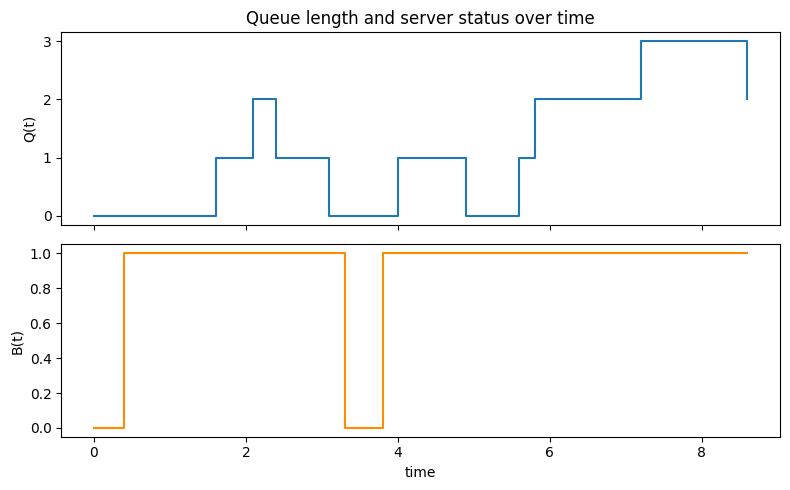

In [30]:
# quick visual: Q(t) and B(t) step plots (useful for sanity-checking a trace)
times = [0.0] + [row[0] for row in trace]
q_hist = [0] + [row[2] for row in trace]
b_hist = [0] + [row[3] for row in trace]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 5))
ax1.step(times, q_hist, where="post")
ax1.set_ylabel("Q(t)")
ax1.set_title("Queue length and server status over time")
ax2.step(times, b_hist, where="post", color="darkorange")
ax2.set_ylabel("B(t)")
ax2.set_xlabel("time")
plt.tight_layout()
plt.show()


### 7.2 Stopping rule variant: stop after a fixed **time** $T_{max}$ instead of after N customers

Same engine, different loop condition — and remember the **tail rectangle** from the last event
up to $T_{max}$ (the state does not change again after the last processed event).

Note: `avg_queue` and `utilization` come out identical to section 7.1 here because $T_{max}=8.6$
happens to land exactly on the same 6th-delay event. `avg_delay` differs on purpose — this rule
averages over *however many customers started service by $T_{max}$*, not a fixed count of 6.

In [31]:
def simulate_by_fixed_time(inter_arrival_times, service_times, T_max):
    INFINITY = math.inf
    clock = 0.0
    time_last_event = 0.0
    server_busy = 0
    num_in_queue = 0
    queue_arrival_times = []
    area_Q = 0.0
    area_B = 0.0
    total_delay = 0.0
    num_served = 0
    arrival_index = 0
    service_index = 0
    next_arrival_time = inter_arrival_times[0]
    next_departure_time = INFINITY

    while True:
        next_event_time = min(next_arrival_time, next_departure_time)
        if next_event_time > T_max:
            break   # stop condition: peek without processing

        dt = next_event_time - time_last_event
        area_Q += num_in_queue * dt
        area_B += server_busy * dt
        time_last_event = next_event_time
        clock = next_event_time

        if next_arrival_time <= next_departure_time:
            if server_busy == 1:
                num_in_queue += 1
                queue_arrival_times.append(clock)
            else:
                server_busy = 1
                num_served += 1
                svc = service_times[service_index]; service_index += 1
                next_departure_time = clock + svc

            arrival_index += 1
            if arrival_index < len(inter_arrival_times):
                next_arrival_time = clock + inter_arrival_times[arrival_index]
            else:
                next_arrival_time = INFINITY
        else:
            if num_in_queue == 0:
                server_busy = 0
                next_departure_time = INFINITY
            else:
                num_in_queue -= 1
                arrived_at = queue_arrival_times.pop(0)
                total_delay += clock - arrived_at
                num_served += 1
                svc = service_times[service_index]; service_index += 1
                next_departure_time = clock + svc

    # tail rectangle: state is unchanged from the last event to T_max
    area_Q += num_in_queue * (T_max - time_last_event)
    area_B += server_busy * (T_max - time_last_event)

    avg_delay = total_delay / num_served if num_served > 0 else 0.0
    avg_queue_length = area_Q / T_max
    server_utilization = area_B / T_max
    return avg_delay, avg_queue_length, server_utilization


avg_delay, avg_queue, utilization = simulate_by_fixed_time(inter_arrival_times, service_times, T_max=8.6)
print(f"avg_delay={avg_delay:.4f}  avg_queue={avg_queue:.4f}  utilization={utilization:.4f}")


avg_delay=0.5400  avg_queue=1.1512  utilization=0.8953


### 7.3 Multi-Server Queue (e.g. 2 identical servers, 1 shared queue)

Same idea, but `server_busy` becomes a list, one entry per server; an arrival takes **any** idle
server, and the queue only grows when **all** servers are busy.

In [32]:
def simulate_multi_server_queue(inter_arrival_times, service_times, num_servers):
    N = min(len(inter_arrival_times), len(service_times))
    INFINITY = math.inf

    clock = 0.0
    time_last_event = 0.0

    server_busy = [0] * num_servers            # 0 = idle, 1 = busy, per server
    next_departure = [INFINITY] * num_servers    # each server's own departure time

    num_in_queue = 0
    queue_arrival_times = []

    area_Q = 0.0
    area_B = 0.0          # area under TOTAL busy-servers count
    total_delay = 0.0
    num_served = 0

    arrival_index = 0
    service_index = 0
    next_arrival_time = inter_arrival_times[0]

    while arrival_index < N or sum(server_busy) > 0 or num_in_queue > 0:
        next_departure_time = min(next_departure)
        next_event_time = min(next_arrival_time, next_departure_time)

        dt = next_event_time - time_last_event
        area_Q += num_in_queue * dt
        area_B += sum(server_busy) * dt
        time_last_event = next_event_time
        clock = next_event_time

        if next_arrival_time <= next_departure_time:
            # find an idle server, if any
            idle_server = None
            for s in range(num_servers):
                if server_busy[s] == 0:
                    idle_server = s
                    break

            if idle_server is None:
                num_in_queue += 1
                queue_arrival_times.append(clock)
            else:
                server_busy[idle_server] = 1
                num_served += 1
                svc = service_times[service_index]; service_index += 1
                next_departure[idle_server] = clock + svc

            arrival_index += 1
            if arrival_index < N:
                next_arrival_time = clock + inter_arrival_times[arrival_index]
            else:
                next_arrival_time = INFINITY
        else:
            server_id = next_departure.index(next_departure_time)
            if num_in_queue == 0:
                server_busy[server_id] = 0
                next_departure[server_id] = INFINITY
            else:
                num_in_queue -= 1
                arrived_at = queue_arrival_times.pop(0)
                total_delay += clock - arrived_at
                num_served += 1
                svc = service_times[service_index]; service_index += 1
                next_departure[server_id] = clock + svc

    avg_delay = total_delay / N
    avg_queue_length = area_Q / clock
    # utilization per server = area_B / (T * num_servers)
    server_utilization = area_B / (clock * num_servers)
    return avg_delay, avg_queue_length, server_utilization, clock


inter_arrival_times2 = [2, 3, 1, 4, 2, 5, 1, 3]
service_times2       = [4, 2, 3, 1, 2, 3, 2, 4]

avg_delay, avg_queue, utilization, T = simulate_multi_server_queue(inter_arrival_times2, service_times2, num_servers=2)
print(f"T={T:.2f}  avg_delay={avg_delay:.4f}  avg_queue={avg_queue:.4f}  utilization={utilization:.4f}")


T=25.00  avg_delay=0.0000  avg_queue=0.0000  utilization=0.4200


### 7.4 Computing performance from a **given trace table** (no simulation needed)

Sometimes the exam already gives you the event times and the state after each event — you just
need to sum up rectangle areas.

In [33]:
def performance_from_trace(delays, event_times, Q_after, B_after):
    """
    delays      : list of each customer's delay (0.0 if server was idle on arrival)
    event_times : [t0=0, t1, t2, ..., tN=T]  (N+1 entries, includes start and end)
    Q_after[i]  : queue length just AFTER event i, held during [t_i, t_{i+1}]
    B_after[i]  : server status (0/1) just AFTER event i, same interval
    """
    T = event_times[-1]

    area_Q = 0.0
    area_B = 0.0
    for i in range(len(Q_after)):
        width = event_times[i + 1] - event_times[i]
        area_Q += Q_after[i] * width
        area_B += B_after[i] * width

    avg_delay = sum(delays) / len(delays)
    avg_queue_length = area_Q / T
    server_utilization = area_B / T
    return avg_delay, avg_queue_length, server_utilization


# Example trace matching the single-server simulation above (13 intervals)
delays      = [0.0, 0.8, 1.0, 0.0, 0.9, 3.0]
event_times = [0.0, 0.4, 1.6, 2.1, 2.4, 3.1, 3.3, 3.8, 4.0, 4.9, 5.6, 5.8, 7.2, 8.6]
Q_after     = [0,   0,   1,   2,   1,   0,   0,   0,   1,   0,   1,   2,   3]
B_after     = [0,   1,   1,   1,   1,   1,   0,   1,   1,   1,   1,   1,   1]

avg_delay, avg_queue, utilization = performance_from_trace(delays, event_times, Q_after, B_after)
print(f"avg_delay={avg_delay:.4f}  avg_queue={avg_queue:.4f}  utilization={utilization:.4f}")


avg_delay=0.9500  avg_queue=1.1512  utilization=0.8953


## 8. SciPy Quick Reference (`scipy.stats`)

One-stop lookup for every SciPy call used above.

In [34]:
alpha = 0.05

# ---- Chi-Square test ----
df = 9   # degrees of freedom = number_of_bins - 1
print("chi-square critical value:", stats.chi2.ppf(1 - alpha, df))
print("chi-square p-value for stat=12.3:", stats.chi2.sf(12.3, df))
counts_example = [8, 12, 9, 11, 10, 9, 11, 10, 10, 10]
chi2_stat, p_value = stats.chisquare(counts_example)          # quick built-in shortcut
print("stats.chisquare shortcut -> chi2:", round(chi2_stat, 4), " p:", round(p_value, 4))

# ---- Kolmogorov-Smirnov test ----
N = 5
print("\nK-S critical value:", stats.ksone.ppf(1 - alpha, N))
print("K-S p-value for D=0.26:", 1 - stats.ksone.cdf(0.26, N))
print("stats.kstest shortcut:", stats.kstest([0.44, 0.81, 0.14, 0.05, 0.93], "uniform"))

# ---- Autocorrelation / Runs test (both use the Normal distribution) ----
print("\nz critical value (alpha=0.05, two-tailed):", stats.norm.ppf(1 - alpha/2))     # 1.96
Z0_example = -1.52
print("p-value for Z0 = -1.52:", 2 * (1 - stats.norm.cdf(abs(Z0_example))))

# ---- Pearson correlation, an alternative sanity check for lag-1 autocorrelation ----
x = [0.23, 0.28, 0.33, 0.27, 0.05]
y = [0.28, 0.33, 0.27, 0.05, 0.36]
correlation, p_value = stats.pearsonr(x, y)
print("\nPearson correlation (lag-1 sanity check):", round(correlation, 4), " p:", round(p_value, 4))


chi-square critical value: 16.918977604620448
chi-square p-value for stat=12.3: 0.1969202263985533
stats.chisquare shortcut -> chi2: 1.2  p: 0.9988

K-S critical value: 0.5094493282201104
K-S p-value for D=0.26: 0.4375760704
stats.kstest shortcut: KstestResult(statistic=np.float64(0.26), pvalue=np.float64(0.81234688), statistic_location=np.float64(0.14), statistic_sign=np.int8(1))

z critical value (alpha=0.05, two-tailed): 1.959963984540054
p-value for Z0 = -1.52: 0.12851097563787173

Pearson correlation (lag-1 sanity check): -0.4161  p: 0.4859


In [54]:
n = 42
f"{n:8d}"     # '      42'   right-aligned (default for numbers)
f"{n:<8d}"    # '42      '   left-aligned
f"{n:^8d}"    # '   42   '   centered
f"{n:*>8d}"   # '******42'   fill char '*' + right align
f"{n:*<8d}"   # '42******'
f"{n:*^8d}"   # '***42***'

s = "hi"
f"{s:8s}"     # 'hi      '   strings are LEFT-aligned by default
f"{s:>8s}"    # '      hi'



x = 3.14159
f"{x:.2f}"     # '3.14'
f"{x:.4f}"     # '3.1416'   (rounded)
f"{x:.0f}"     # '3'
f"{2.5:.4f}"   # '2.5000'   ← trailing zeros appear automatically

f"{x:8.2f}"    # '    3.14'   space-padded to width 8
f"{x:08.2f}"   # '00003.14'   zero-padded to width 8

'00003.14'

## 9. Decision-Rule Cheat Sheet

| Test | Null hypothesis $H_0$ | Statistic | Reject $H_0$ when (alpha = 0.05) |
|---|---|---|---|
| Chi-Square | sample is uniform | $\sum (O_i-E_i)^2/E_i$ | $\chi_0^2 > \chi^2_{0.05,\,k-1}$, or $p < 0.05$ |
| K-S | sample is uniform | $D=\max(D^+,D^-)$ | $D > D_{critical}$ |
| Autocorrelation | values are independent | $Z_0=\hat\rho/\sigma_{\hat\rho}$ | $\lvert Z_0\rvert > 1.96$ |
| Runs test | values are independent | $Z_0=(\text{runs}-E[\text{runs}])/\sqrt{\text{Var}}$ | $\lvert Z_0\rvert > 1.96$ |

**General workflow for an RNG exam question:**
1. Generate the sequence (LCG / Middle-Square / given values).
2. Test uniformity (Chi-Square and/or K-S).
3. Test independence (Autocorrelation and/or Runs).
4. State $H_0$, the statistic, the critical value/p-value, and the decision explicitly.

**General workflow for a queue-simulation question:**
1. Identify inter-arrival times and service times (or the given trace table).
2. Advance the clock event-by-event (arrival vs departure), updating `area_Q`/`area_B`
   **before** changing the state.
3. Track `total_delay` (only accumulated when a *waiting* customer starts service, not on
   immediate service).
4. Report `avg_delay = total_delay / N`, `avg_queue = area_Q / T`, `utilization = area_B / T`.


**B2**

In [5]:
def msws_generator ( n_samples , x0 =0 , w0 =0 , c =0xb5ad4ec5 , m =2**32) :

        
        X=x0
        w=w0
        U_values = []
        for i in range(n_samples):
            w= (w +c ) % m
            X = ((X**2) + w) % m
            U = math.floor(X / (2 ** 16))/(2**16)
            U_values.append(U)
        return U_values
    
    
N = 10000
U_n = msws_generator(4 * N)          # need 4 uniforms per replication

def to_exp(u, beta):
    return -beta * math.log(1 - u)

betas = [10, 8, 7, 5]   # beta1..beta4
survive = 0
for k in range(N):
    u1, u2, u3, u4 = U_n[4*k], U_n[4*k+1], U_n[4*k+2], U_n[4*k+3]
    X1 = to_exp(u1, betas[0])
    X2 = to_exp(u2, betas[1])
    X3 = to_exp(u3, betas[2])
    X4 = to_exp(u4, betas[3])

    # topology: A -> 2 -> B   in parallel with   A -> 1 -> (3 || 4) -> B
    lower_branch = min(X1, max(X3, X4))     # series: 1 then (3 parallel 4)
    Y = max(X2, lower_branch)               # parallel: branch-2 vs branch-1341

    if Y >= 7:
        survive += 1

p_hat = survive / N
print("p_hat =", p_hat)


p_hat = 0.5709


**C1**

## 2. Digit Manipulation Tricks (needed for Middle-Square)

The Middle-Square generator squares a number, pads it to a fixed width with leading zeros, then
slices out the middle digits. This only needs basic string formatting and slicing.

In [66]:
seed = 5731
# square = seed * seed
# print("seed:", seed, " square:", square)

# # pad the square to exactly 8 digits with leading zeros
# padded = f"{square:08d}"
# print("padded to 8 digits:", padded)

# # # take the middle 4 digits: string positions 2,3,4,5 (0-indexed, end exclusive)
# middle_four = padded[2:6]
# print("middle four digits (string):", middle_four)
# print("middle four digits (int):  ", int(middle_four))

# # # small worked table for several seeds
# seeds_to_try = [5731, 8443, 769, 2500]
# print()
# print(f"{'seed':>6} | {'square':>10} | {'8-digit square':>14} | {'middle four':>11}")
# for s in seeds_to_try:
#     sq = s * s
#     pad = f"{sq:08d}"
#     mid = pad[2:6]
#     print(f"{s:6d} | {sq:10d} | {pad:>14} | {mid:>11}")


def middle_square_generator(n_samples, seed):
    X = seed
    U_values = []
    for i in range(n_samples):
        square = X * X
        padded = f"{square:08d}"
        middle_four = padded[2:6]
        X = int(middle_four)
        U = X / 10000.0
        U_values.append(U)
    return U_values

U_n = middle_square_generator(1000, seed=6239)
for values in U_n:
    print(f"{values:.4f}", end=" ")



def chi_square_test(sample, bins=10, alpha=0.05, low=0.0, high=1.0):
    """Manual Chi-Square uniformity test. No library functions used for the statistic itself."""
    n = len(sample)
    width = (high - low) / bins

    # Step 1: count observed values in each bin
    counts = [0] * bins
    for value in sample:
        idx = int((value - low) / width)
        if idx == bins:          # value exactly equal to 'high' goes in the last bin
            idx = bins - 1
        counts[idx] += 1

    # Step 2: chi-square statistic
    E = n / bins
    chi2_stat = 0.0
    for i in range(bins):
        chi2_stat += ((counts[i] - E) ** 2) / E

    # Step 3: critical value & p-value (via SciPy, degrees of freedom = bins - 1)
    df = bins - 1
    critical_value = stats.chi2.ppf(1 - alpha, df)
    p_value = stats.chi2.sf(chi2_stat, df)

    decision = "Reject H0 (NOT uniform)" if chi2_stat > critical_value else "Fail to reject H0 (uniform)"
    return counts, chi2_stat, critical_value, p_value, decision


# EXAM: paste your sample values here
# sample = R_vals + uniform_5_10  # placeholder demo data - REPLACE with the exam's sample
# sample = [random.random() for _ in range(1000)]   # bigger demo sample so 10 bins makes sense
sample = U_n

counts, chi2_stat, crit, p_val, decision = chi_square_test(sample, bins=10, alpha=0.05)
print("observed counts per bin:", counts)
print(f"chi-square statistic = {chi2_stat:.4f}")
print(f"critical value (df=9, alpha=0.05) = {crit:.4f}")
print(f"p-value = {p_val:.6f}")
print("decision:", decision)

# cross-check with SciPy's built-in shortcut (same numbers)
chi2_scipy, p_scipy = stats.chisquare(counts)
print("\nSciPy cross-check -> chi2:", round(chi2_scipy, 4), " p-value:", round(p_scipy, 6))



0.9251 0.5810 0.7561 0.1687 0.8459 0.5546 0.7581 0.4715 0.2312 0.3453 0.9232 0.2298 0.2808 0.8848 0.2871 0.2426 0.8854 0.3933 0.4684 0.9398 0.3224 0.3941 0.5314 0.2385 0.6882 0.3619 0.0971 0.9428 0.8871 0.6946 0.2469 0.0959 0.9196 0.5664 0.0808 0.6528 0.6147 0.7856 0.7167 0.3658 0.3809 0.5084 0.8470 0.7409 0.8932 0.7806 0.9336 0.1608 0.5856 0.2927 0.5673 0.1829 0.3452 0.9163 0.9605 0.2560 0.5536 0.6472 0.8867 0.6236 0.8876 0.7833 0.3558 0.6593 0.4676 0.8649 0.8052 0.8347 0.6724 0.2121 0.4986 0.8601 0.9772 0.4919 0.1965 0.8612 0.1665 0.7722 0.6292 0.5892 0.7156 0.2083 0.3388 0.4785 0.8962 0.3174 0.0742 0.5505 0.3050 0.3025 0.1506 0.2680 0.1824 0.3269 0.6863 0.1007 0.0140 0.0196 0.0384 0.1474 0.1726 0.9790 0.8441 0.2504 0.2700 0.2900 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100 0.8100 0.6100 0.2100 0.4100

### A1

In [29]:
# random.seed(42)
import random

def monte_carlo_pi(n_drops, seed=42, L=1.0, D=2.0):
    if seed is not None:
        random.seed(seed)
    hits = 0
    for i in range(n_drops):
        # x = random.random()
        x = 0 + (D/2) * random.random()
        theta = 0 + (math.pi/2)*random.random()
        # y = random.random()
        # if x**2 + y**2 <= 1:
        if x <= (L/2)*math.sin(theta):
            hits += 1
    p_hat=hits/n_drops
    pi_estimate = 2*L*n_drops/(D*hits)
    absolute_error = abs(((pi_estimate - math.pi)/math.pi) * 100.0)
        # absolute_error=1
        
    return hits, p_hat, pi_estimate, absolute_error

N=[100, 1000, 10000, 100000, 1000000]

for n_drops in N:
    print(n_drops)
    hits, p_hat, pi_estimate, absolute_error = monte_carlo_pi(n_drops)
    print(f"n_drops={n_drops} hits = {hits} , pi_hat = {p_hat:.4f} , pi_est = {pi_estimate:.4f} , abs_err = {absolute_error:.4f}")


100
n_drops=100 hits = 32 , pi_hat = 0.3200 , pi_est = 3.1250 , abs_err = 0.5282
1000
n_drops=1000 hits = 305 , pi_hat = 0.3050 , pi_est = 3.2787 , abs_err = 4.3639
10000
n_drops=10000 hits = 3198 , pi_hat = 0.3198 , pi_est = 3.1270 , abs_err = 0.4660
100000
n_drops=100000 hits = 31921 , pi_hat = 0.3192 , pi_est = 3.1327 , abs_err = 0.2820
1000000
n_drops=1000000 hits = 318470 , pi_hat = 0.3185 , pi_est = 3.1400 , abs_err = 0.0503


### C2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import math
import random

# make plots a reasonable size by default
plt.rcParams["figure.figsize"] = (8, 4)


def lcg(seed, a, c, m, n):
    """Generate n values with a Linear Congruential Generator (plain loop, no generator/yield)."""
    X = seed
    X_values = []
    R_values = []
    for i in range(n):
        X = (a * X + c) % m
        R = X / m
        X_values.append(X)
        R_values.append(R)
    return X_values, R_values


# EXAM: change these 5 numbers to match the question
seed, a, c, m, n = 1, 5, 0, 2**16, 100000

X_vals, R_vals = lcg(seed, a, c, m, n)

# print(f"{'i':>3} | {'X_i':>6} | {'R_i = X_i/m':>12}")
# for i in range(n):
#     print(f"{i+1:3d} | {X_vals[i]:6d} | {R_vals[i]:12.4f}")


def ks_test(sample, alpha=0.05):
    """Manual K-S test for uniformity on [0,1]. sample values assumed already in [0,1]."""
    N = len(sample)
    s = sorted(sample)

    D_plus = float("-inf")
    D_minus = float("-inf")
    for i in range(1, N + 1):
        d_plus_i = i / N - s[i - 1]
        d_minus_i = s[i - 1] - (i - 1) / N
        if d_plus_i > D_plus:
            D_plus = d_plus_i
        if d_minus_i > D_minus:
            D_minus = d_minus_i

    D = max(D_plus, D_minus)

    # SciPy gives the exact critical value / p-value for ANY N and alpha
    # D_critical = stats.ksone.ppf(1 - alpha, N)
    D_critical = 1.36 / math.sqrt(N)
    p_value = 1 - stats.ksone.cdf(D, N)

    decision = "Reject H0 (NOT uniform)" if D > D_critical else "Fail to reject H0 (uniform)"
    return D, D_plus, D_minus, D_critical, p_value, decision


# EXAM slide example
sample = R_vals
D, Dp, Dm, Dc, p, decision = ks_test(sample, alpha=0.05)
print(f"D+ = {Dp:.4f}   D- = {Dm:.4f}   D = {D:.4f}")
print(f"D_critical = {Dc:.4f}   p-value = {p:.4f}")
print("decision:", decision)

# cross-check with SciPy's built-in one-line K-S test
result = stats.kstest(sample, "uniform")
print("\nSciPy cross-check:", result)



D+ = 0.0005   D- = 0.0002   D = 0.0005
D_critical = 0.0043   p-value = 0.9576
decision: Fail to reject H0 (uniform)

SciPy cross-check: KstestResult(statistic=np.float64(0.00046378417968750973), pvalue=np.float64(1.0), statistic_location=np.float64(0.2429962158203125), statistic_sign=np.int8(1))
